[Cell1]

In [1]:
import os, socket, tensorflow as tf

print("host:", socket.gethostname())
print("gpus:", tf.config.list_physical_devices("GPU"))
print("SLURM_CPUS_PER_TASK:", os.environ.get("SLURM_CPUS_PER_TASK"))

2026-05-30 22:24:58.352525: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-30 22:24:58.394626: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-30 22:25:00.125943: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


host: ego-g01.hl.com
gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
SLURM_CPUS_PER_TASK: 16


In [2]:
import os
import random
import numpy as np
import tensorflow as tf

def set_deterministic_seed(seed=42):
    # 1. OS 환경 변수 통제 (GPU 연산 고정)
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. 난수 생성기 고정
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # 3. 💡 [핵심] TensorFlow 내부 GPU/CPU 오퍼레이션의 결정론적 실행 강제
    # 주의: 이 옵션을 켜면 학습 속도가 5~10% 정도 미세하게 느려질 수 있습니다.
    tf.config.experimental.enable_op_determinism() 
    
    print(f"🔒 GPU 연산까지 완벽하게 통제된 시드({seed})가 설정되었습니다.")

set_deterministic_seed(42)

🔒 GPU 연산까지 완벽하게 통제된 시드(42)가 설정되었습니다.


[Cell2]

In [3]:
NUM_SAMPLES = 50000
NUM_HOURS = 24
NUM_GENS = 54

# 변환된 .npz 파일 로드
data = np.load('/home/yoonjoo_chae/AIUC/uc_new_data.npz')

X_demand = data['X_demand']
Y_status = data['Y_status']
Y_power  = data['Y_power']

print("=== 데이터 로드 완료 ===")
print("X_demand shape:", X_demand.shape)   # 기대값: (10000, 24, 1)
print("Y_status shape:", Y_status.shape)   # 기대값: (10000, 24, 54)
print("Y_power shape:", Y_power.shape)     # 기대값: (10000, 24, 54)

=== 데이터 로드 완료 ===
X_demand shape: (50000, 24, 1)
Y_status shape: (50000, 24, 54)
Y_power shape: (50000, 24, 54)


[Cell2.5]

In [4]:
# ---------------------------------------------------------
# [새로운 cell 2.5] 정적(Static) 데이터 파싱 및 X_static 생성
# ---------------------------------------------------------
import pandas as pd
import io

# 1. 제공된 데이터를 CSV 문자열로 정의 (주석 및 빈 줄 제외하고 복사)
csv_data = """Bus,MaxProd,MinProd,IniProd,IniState,SUcap,SDcap,RampUp,RampDw,FuelCost,SlopeVarCost,InterVarCost,OMVarCost,MinTU,MinTD,SDduration,ShutdownCost,SUduration1,DownTtimeforSU1,SUcost1
gen01,4,30,5,30,5,5,5,5,5,1.00,27.08,26.55,0.00,5,4,1,0,1,4,40
gen02,6,30,5,30,5,5,5,5,5,1.00,31.30,25.85,0.00,5,4,1,0,1,4,40
gen03,8,30,5,30,5,5,5,5,5,1.00,27.90,26.10,0.00,5,4,1,0,1,4,40
gen04,10,300,150,0,-13,150,150,150,150,1.00,12.06,8.05,0.00,1,13,2,0,4,13,440
gen05,12,300,100,300,2,100,100,100,100,1.00,11.04,7.82,0.00,2,13,2,0,4,13,110
gen06,15,30,10,30,2,10,10,10,10,1.00,28.51,28.87,0.00,2,4,1,0,1,4,40
gen07,18,100,25,0,-7,25,25,25,25,1.00,14.64,12.26,0.00,3,7,1,0,2,7,50
gen08,19,30,5,30,5,5,5,5,5,1.00,30.45,28.51,0.00,5,4,1,0,1,4,40
gen09,24,30,5,30,5,5,5,5,5,1.00,26.44,26.38,0.00,5,4,1,0,1,4,40
gen10,25,300,100,300,2,100,100,100,100,1.00,11.72,7.12,0.00,2,13,2,0,4,13,100
gen11,26,350,100,300,2.5,100,100,100,100,1.00,10.11,35.59,0.00,3,13,2,0,4,13,100
gen12,27,30,8,0,-4,8,8,8,8,1.00,29.17,29.49,0.00,3,4,1,0,1,4,40
gen13,31,30,8,0,-4,8,8,8,8,1.00,30.89,27.62,0.00,3,4,1,0,1,4,40
gen14,32,100,25,0,-7,25,25,25,25,1.00,14.13,11.96,0.00,3,7,1,0,2,7,50
gen15,34,30,8,30,2.75,8,8,8,8,1.00,29.76,27.95,0.00,3,4,1,0,1,4,40
gen16,36,100,25,0,-7,25,25,25,25,1.00,16.76,11.61,0.00,3,7,1,0,2,7,50
gen17,40,30,8,0,-4,8,8,8,8,1.00,26.76,29.17,0.00,3,4,1,0,1,4,40
gen18,42,30,8,0,-4,8,8,8,8,1.00,28.10,27.25,0.00,3,4,1,0,1,4,40
gen19,46,100,25,0,-7,25,25,25,25,1.00,14.85,10.64,0.00,3,7,1,0,2,7,59
gen20,49,250,50,0,-13,50,50,50,50,1.00,10.83,30.48,0.00,4,13,2,0,4,13,100
gen21,54,250,50,50,4,50,50,50,50,1.00,10.60,30.74,0.00,4,13,2,0,4,13,100
gen22,55,100,25,0,-7,25,25,25,25,1.00,15.37,12.59,0.00,3,7,1,0,2,7,50
gen23,56,100,25,0,-7,25,25,25,25,1.00,15.19,11.87,0.00,3,7,1,0,2,7,50
gen24,59,200,50,0,-13,50,50,50,50,1.00,11.31,43.01,0.00,3,13,2,0,4,13,100
gen25,61,200,50,0,-13,50,50,50,50,1.00,13.01,39.49,0.00,3,13,2,0,4,13,100
gen26,62,100,25,0,-7,25,25,25,25,1.00,15.34,12.12,0.00,3,7,1,0,2,7,50
gen27,65,420,100,100,3.2,100,100,100,100,1.00,7.93,72.78,0.00,3,15,2,0,5,15,250
gen28,66,420,100,100,3.2,100,100,100,100,1.00,8.28,69.33,0.00,3,15,2,0,5,15,250
gen29,69,300,80,0,-13,80,80,80,80,1.00,10.99,7.91,0.00,3,13,2,0,4,13,100
gen30,70,80,30,80,1.666666667,30,30,30,30,1.00,17.83,66.83,0.00,2,7,1,0,2,7,45
gen31,72,30,10,0,-4,10,10,10,10,1.00,29.59,29.35,0.00,2,4,1,0,1,4,40
gen32,73,30,5,0,-4,5,5,5,5,1.00,30.83,27.59,0.00,5,4,1,0,1,4,40
gen33,74,20,5,0,-4,5,5,5,5,1.00,43.75,15.75,0.00,3,4,1,0,1,4,30
gen34,76,100,25,25,3,25,25,25,25,1.00,15.09,11.94,0.00,3,7,1,0,2,7,50
gen35,77,100,25,25,3,25,25,25,25,1.00,15.18,11.93,0.00,3,7,1,0,2,7,50
gen36,80,300,150,0,-13,150,150,150,150,1.00,12.28,8.22,0.00,1,13,2,0,4,13,440
gen37,82,100,25,25,3,25,25,25,25,1.00,14.73,11.73,0.00,3,7,1,0,2,7,50
gen38,85,30,10,0,-4,10,10,10,10,1.00,29.44,29.17,0.00,2,4,1,0,1,4,40
gen39,87,300,100,100,2,100,100,100,100,1.00,10.17,35.29,0.00,2,13,2,0,4,13,440
gen40,89,200,50,50,3,50,50,50,50,1.00,11.14,7.73,0.00,3,13,2,0,4,13,400
gen41,90,20,8,0,-4,8,8,8,8,1.00,44.87,15.22,0.00,2,4,1,0,1,4,30
gen42,91,50,20,40,1.5,20,20,20,20,1.00,23.87,48.05,0.00,2,4,1,0,1,4,45
gen43,92,300,100,100,2,100,100,100,100,1.00,12.65,7.28,0.00,2,13,2,0,4,13,100
gen44,99,300,100,100,2,100,100,100,100,1.00,11.17,7.92,0.00,2,13,2,0,4,13,100
gen45,100,300,100,100,2,100,100,100,100,1.00,12.10,7.41,0.00,2,13,2,0,4,13,110
gen46,103,20,8,0,-4,8,8,8,8,1.00,40.36,16.74,0.00,2,4,1,0,1,4,30
gen47,104,100,25,0,-7,25,25,25,25,1.00,14.73,11.24,0.00,3,7,1,0,2,7,50
gen48,105,100,25,0,-7,25,25,25,25,1.00,15.41,11.25,0.00,3,7,1,0,2,7,50
gen49,107,20,8,0,-4,8,8,8,8,1.00,40.55,15.77,0.00,2,4,1,0,1,4,30
gen50,110,50,25,40,1,25,25,25,25,1.00,25.28,48.88,0.00,1,4,1,0,1,4,45
gen51,111,100,25,0,-7,25,25,25,25,1.00,15.01,11.18,0.00,3,7,1,0,2,7,50
gen52,112,100,25,0,-7,25,25,25,25,1.00,15.01,10.93,0.00,3,7,1,0,2,7,50
gen53,113,100,25,0,-7,25,25,25,25,1.00,16.22,12.04,0.00,3,7,1,0,2,7,50
gen54,116,50,25,50,1,25,25,25,25,1.00,26.73,50.68,0.00,1,4,1,0,1,4,45"""

df = pd.read_csv(io.StringIO(csv_data))

LINEAR_COST_VALS = df['SlopeVarCost'].values  # 2차(또는 선형) 비용 계수
NOLOAD_COST_VALS = df['InterVarCost'].values  # 1차(또는 절편) 비용 계수
SU_COST_VALS = df['SUcost1'].values      # 기동 비용 (Start-up Cost)

MUT_VALS = df['MinTU'].values.astype(int)
MDT_VALS = df['MinTD'].values.astype(int)

# 2. 4개의 핵심 Feature 추출 및 정규화 (스케일링 지옥 방지)
# (1) Init_Status: IniState가 0보다 크면 1(켜짐), 아니면 0(꺼짐)
f_init_status = (df['IniState'] > 0).astype(float).values

# (2) Init_Power: P_max로 나누어 0~1 사이로 정규화
f_init_power = (df['IniProd'] / df['MaxProd']).values

# (3) Cost 1 (SlopeVarCost): 최대값으로 나누어 0~1 사이로 정규화
f_cost1 = (df['SlopeVarCost'] / df['SlopeVarCost'].max()).values

# (4) Cost 2 (InterVarCost): 최대값으로 나누어 0~1 사이로 정규화
f_cost2 = (df['InterVarCost'] / df['InterVarCost'].max()).values

# 3. 54개 발전기의 (54, 4) 배열 생성 후 (216,) 1차원 벡터로 평탄화
# 순서: [발전기1상태, 발전기1파워, 발전기1코스트1, 발전기1코스트2, 발전기2상태... ]
static_features_1d = np.column_stack((f_init_status, f_init_power, f_cost1, f_cost2)).flatten()

# 4. 10000개의 샘플 수에 맞게 동일한 초기값 배열을 복제
# (주의: 만약 10000개 데이터의 시작점이 매번 다르면, 이 배열을 데이터셋에서 따로 뽑아야 함!
# 현재는 118-bus 고정 스펙이므로 똑같이 복제함)
X_static = np.tile(static_features_1d, (NUM_SAMPLES, 1))

print("X_static shape:", X_static.shape) # 기대값: (10000, 216)

X_static shape: (50000, 216)


[Cell3]

In [5]:
# ---------------------------------------------------------
# [수정된 cell 3] Train, Val, Test 데이터 분할 (Static 추가)
# ---------------------------------------------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# (기존의 Power 정규화 로직 유지)
Y_power_2d = Y_power.reshape(-1, NUM_GENS)
scaler_power = MinMaxScaler()
Y_power_scaled_2d = scaler_power.fit_transform(Y_power_2d)
Y_power_scaled = Y_power_scaled_2d.reshape(-1, NUM_HOURS, NUM_GENS)

# 💡 수정 포인트: train_test_split에 X_static 추가!
X_demand_train, X_demand_temp, X_static_train, X_static_temp, Y_status_train, Y_status_temp, Y_power_train, Y_power_temp = train_test_split(
    X_demand, X_static, Y_status, Y_power_scaled, test_size=0.2, random_state=42
)

# Temp 20% -> Val 10%, Test 10%
X_demand_val, X_demand_test, X_static_val, X_static_test, Y_status_val, Y_status_test, Y_power_val, Y_power_test = train_test_split(
    X_demand_temp, X_static_temp, Y_status_temp, Y_power_temp, test_size=0.5, random_state=42
)

print(f"Train samples: {len(X_demand_train)}")
print(f"Val samples: {len(X_demand_val)}")
print(f"Test samples: {len(X_demand_test)}")

Train samples: 40000
Val samples: 5000
Test samples: 5000


[Cell4]

In [6]:
# ---------------------------------------------------------
# [수정된 최종 cell 4] 스케일링 버그 수정 및 정규화 최적화
# ---------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Bidirectional, LSTM, Multiply, Concatenate, RepeatVector, Layer, Lambda
from tensorflow.keras.models import Model

# 정적 데이터 추출
P_MAX_VALS = df['MaxProd'].values
P_MIN_VALS = df['MinProd'].values
RU_VALS = df['RampUp'].values
RD_VALS = df['RampDw'].values

# STE 함수
def ste_binarize(x):
    return x + tf.stop_gradient(tf.round(x) - x)

# ---------------------------------------------------------
# 💡 버그가 수정된 하이브리드 레이어
# ---------------------------------------------------------
class HybridPILossLayer(Layer):
    def __init__(self, p_max, p_min, ru, rd, **kwargs):
        super(HybridPILossLayer, self).__init__(**kwargs)
        self.p_max = tf.constant(p_max, dtype=tf.float32)
        self.p_min = tf.constant(p_min, dtype=tf.float32)
        self.ru = tf.constant(ru, dtype=tf.float32)
        self.rd = tf.constant(rd, dtype=tf.float32)

    def call(self, inputs):
        demand_mw_input, status_ste, out_power = inputs

        # (1) MW 단위 복원
        pred_power_mw = out_power * self.p_max

        # 🚨 [버그 수정] demand는 이미 MW 단위이므로 sys_cap 곱하기를 제거합니다!
        demand_mw = tf.squeeze(demand_mw_input, axis=-1)

        # (2) Mismatch 페널티
        pred_total = tf.reduce_sum(pred_power_mw, axis=-1)
        mismatch_penalty = tf.reduce_mean(tf.abs(pred_total - demand_mw))

        # (3) Capacity 페널티
        upper_violation = tf.maximum(pred_power_mw - self.p_max, 0.0) * status_ste
        lower_violation = tf.maximum(self.p_min - pred_power_mw, 0.0) * status_ste
        capacity_penalty = tf.reduce_mean(tf.reduce_sum(upper_violation + lower_violation, axis=-1))

        # (4) Ramp Rate 페널티
        delta_p = pred_power_mw[:, 1:, :] - pred_power_mw[:, :-1, :]
        stay_on_mask = status_ste[:, 1:, :] * status_ste[:, :-1, :]
        ramp_up_violation = tf.maximum(delta_p - self.ru, 0.0) * stay_on_mask
        ramp_down_violation = tf.maximum(-delta_p - self.rd, 0.0) * stay_on_mask
        ramp_penalty = tf.reduce_mean(tf.reduce_sum(ramp_up_violation + ramp_down_violation, axis=-1))

        w_mismatch = 1.0  # 수요를 맞추는 것을 최우선 목표로 강제! (기존 대비 10배)
        w_capacity = 1.0   # 발전기 보호는 기본 유지
        w_ramp = 1.0       # 증감발률 보호도 기본 유지

        total_penalty = (w_mismatch * mismatch_penalty +
                         w_capacity * capacity_penalty +
                         w_ramp * ramp_penalty) / 10000.0

        self.add_loss(total_penalty)

        return out_power

# ---------------------------------------------------------
# 모델 아키텍처 조립
# ---------------------------------------------------------
def build_hybrid_uc_model(num_hours=24, num_gens=54, num_static_features=4):
    input_dynamic = Input(shape=(num_hours, 1), name='demand_input')
    static_dim = num_gens * num_static_features
    input_static = Input(shape=(static_dim,), name='static_initial_input')

    static_encoded = Dense(64, activation='relu', name='static_encoder')(input_static)
    static_repeated = RepeatVector(num_hours, name='static_repeater')(static_encoded)
    merged_input = Concatenate(axis=-1, name='feature_fusion')([input_dynamic, static_repeated])

    x = Bidirectional(LSTM(256, return_sequences=True))(merged_input)
    x = Bidirectional(LSTM(256, return_sequences=True))(x)
    x = Dense(128, activation='relu')(x)

    out_status = Dense(num_gens, activation='sigmoid', name='out_status')(x)
    status_ste = Lambda(ste_binarize, name='status_ste')(out_status)

    raw_power = Dense(num_gens, activation='sigmoid', name='raw_power')(x)
    out_power_raw = Multiply(name='out_power_raw')([raw_power, status_ste])

    # sys_cap 파라미터 제거
    out_power = HybridPILossLayer(
        P_MAX_VALS, P_MIN_VALS, RU_VALS, RD_VALS, name='out_power'
    )([input_dynamic, status_ste, out_power_raw])

    model = Model(inputs=[input_dynamic, input_static], outputs=[out_status, out_power])
    return model

NUM_STATIC_FEATURES = 4
model = build_hybrid_uc_model(NUM_HOURS, NUM_GENS, NUM_STATIC_FEATURES)

I0000 00:00:1780147505.465648 1985203 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22147 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:38:00.0, compute capability: 8.9


[Cell5]

In [7]:
import tensorflow as tf

# ---------------------------------------------------------
# 1. 54개 발전기의 P_min, P_max 하드코딩 (단위: MW)
# ---------------------------------------------------------
P_min_vals = [
    5.0, 5.0, 5.0, 150.0, 100.0, 10.0, 25.0, 5.0, 5.0, 100.0, 100.0, 8.0, 8.0, 25.0, 8.0,
    25.0, 8.0, 8.0, 25.0, 50.0, 50.0, 25.0, 25.0, 50.0, 50.0, 25.0, 100.0, 100.0, 80.0,
    30.0, 10.0, 5.0, 5.0, 25.0, 25.0, 150.0, 25.0, 10.0, 100.0, 50.0, 8.0, 20.0, 100.0,
    100.0, 100.0, 8.0, 25.0, 25.0, 8.0, 25.0, 25.0, 25.0, 25.0, 25.0
]

P_max_vals = [
    30.0, 30.0, 30.0, 300.0, 300.0, 30.0, 100.0, 30.0, 30.0, 300.0, 350.0, 30.0, 30.0,
    100.0, 30.0, 100.0, 30.0, 30.0, 100.0, 250.0, 250.0, 100.0, 100.0, 200.0, 200.0,
    100.0, 420.0, 420.0, 300.0, 80.0, 30.0, 30.0, 20.0, 100.0, 100.0, 300.0, 100.0, 30.0,
    300.0, 200.0, 20.0, 50.0, 300.0, 300.0, 300.0, 20.0, 100.0, 100.0, 20.0, 50.0, 100.0,
    100.0, 100.0, 50.0
]

# ---------------------------------------------------------
# 2. 54개 발전기의 Ramp-Up (RU), Ramp-Down (RD) 하드코딩 (단위: MW/h)
# ---------------------------------------------------------
# (주의: Julia에서는 Ramp 값을 3배 늘렸지만, AI 학습 평가를 위해 원래 스펙을 로드합니다.
# 만약 완화된 3배 스펙을 원하시면 나중에 이 텐서에 * 3.0 을 해주면 됩니다.)
RU_vals = [
    5.0, 5.0, 5.0, 150.0, 100.0, 10.0, 25.0, 5.0, 5.0, 100.0, 100.0, 8.0, 8.0, 25.0, 8.0,
    25.0, 8.0, 8.0, 25.0, 50.0, 50.0, 25.0, 25.0, 50.0, 50.0, 25.0, 100.0, 100.0, 80.0,
    30.0, 10.0, 5.0, 5.0, 25.0, 25.0, 150.0, 25.0, 10.0, 100.0, 50.0, 8.0, 20.0, 100.0,
    100.0, 100.0, 8.0, 25.0, 25.0, 8.0, 25.0, 25.0, 25.0, 25.0, 25.0
]

RD_vals = [
    5.0, 5.0, 5.0, 150.0, 100.0, 10.0, 25.0, 5.0, 5.0, 100.0, 100.0, 8.0, 8.0, 25.0, 8.0,
    25.0, 8.0, 8.0, 25.0, 50.0, 50.0, 25.0, 25.0, 50.0, 50.0, 25.0, 100.0, 100.0, 80.0,
    30.0, 10.0, 5.0, 5.0, 25.0, 25.0, 150.0, 25.0, 10.0, 100.0, 50.0, 8.0, 20.0, 100.0,
    100.0, 100.0, 8.0, 25.0, 25.0, 8.0, 25.0, 25.0, 25.0, 25.0, 25.0
]

# ---------------------------------------------------------
# 3. TensorFlow 상수(Tensor)로 변환 (Loss 함수 연산용)
# ---------------------------------------------------------
p_min_tensor = tf.constant(P_min_vals, dtype=tf.float32)
p_max_tensor = tf.constant(P_max_vals, dtype=tf.float32)
ru_tensor = tf.constant(RU_vals, dtype=tf.float32)
rd_tensor = tf.constant(RD_vals, dtype=tf.float32)

# 이전 코드 호환용: P_MAX_tensor가 역정규화에 쓰이고 있었으므로 매핑
P_MAX_tensor = p_max_tensor

print("✅ 54개 발전기의 물리적 제약조건 텐서가 메모리에 정상적으로 등록되었습니다!")

✅ 54개 발전기의 물리적 제약조건 텐서가 메모리에 정상적으로 등록되었습니다!


[Cell6]

In [8]:
# ---------------------------------------------------------
# 6. Phase 1 컴파일 및 학습 (Status Focus)
# ---------------------------------------------------------
print("=== Phase 1: 발전기 Status(On/Off) 집중 학습 시작 ===")

losses = {
    'out_status': 'binary_crossentropy',
    'out_power': 'mse'
}

loss_weights_phase1 = {
    'out_status': 1.0,
    'out_power': 0.0
}

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=losses,
    loss_weights=loss_weights_phase1,
    metrics = {
    'out_status': [tf.keras.metrics.BinaryAccuracy(name='accuracy')],
    'out_power': ['mae']
    }
)

es_phase1 = tf.keras.callbacks.EarlyStopping(
    monitor='val_out_status_loss',
    patience=10,
    restore_best_weights=True,
    mode='min'
)

EPOCHS_PHASE1 = 30
BATCH_SIZE = 64

history_phase1 = model.fit(
    x=[X_demand_train, X_static_train],
    y={'out_status': Y_status_train, 'out_power': Y_power_train},
    validation_data=(
        [X_demand_val, X_static_val],
        {'out_status': Y_status_val, 'out_power': Y_power_val}
    ),
    epochs=EPOCHS_PHASE1,
    batch_size=BATCH_SIZE,
    callbacks=[es_phase1],
    verbose=2
)
print("=== Phase 1 학습 종료 ===")

=== Phase 1: 발전기 Status(On/Off) 집중 학습 시작 ===
Epoch 1/30


2026-05-30 22:25:09.162945: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2194 - out_power_loss: 0.0540 - out_power_mae: 0.0825 - out_status_accuracy: 0.9366 - out_status_loss: 0.1599

2026-05-30 22:25:15.885536: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_17}}


625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.2190 - out_power_loss: 0.0539 - out_power_mae: 0.0824 - out_status_accuracy: 0.9367 - out_status_loss: 0.1596 - val_loss: 0.0848 - val_out_power_loss: 0.0217 - val_out_power_mae: 0.0417 - val_out_status_accuracy: 0.9751 - val_out_status_loss: 0.0721
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0854 - out_power_loss: 0.0211 - out_power_mae: 0.0417 - out_status_accuracy: 0.9747 - out_status_loss: 0.0715 - val_loss: 0.0783 - val_out_power_loss: 0.0169 - val_out_power_mae: 0.0367 - val_out_status_accuracy: 0.9769 - val_out_status_loss: 0.0679
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0765 - out_power_loss: 0.0174 - out_power_mae: 0.0374 - out_status_accuracy: 0.9775 - out_status_loss: 0.0656 - val_loss: 0.0743 - val_out_power_loss: 0.0170 - val_out_power_mae: 0.0363 - val_out_status_accuracy: 0.9785 - val_out_status_loss: 0.0638
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0726 - o

[Cell7]

In [9]:
# ---------------------------------------------------------
# [최종 cell 7] Phase 2: 하이브리드 미세조정 (자체 PI Loss 내장)
# ---------------------------------------------------------
print("=== Phase 2: 하이브리드(STE + Comprehensive PI Loss) 미세조정 시작 ===")

# 모든 물리 제약이 Layer 내부에 구현되어 있으므로,
# 컴파일 시에는 순수 데이터 정답지(Label)를 맞추기 위한 기본 Loss만 지정하면 됩니다.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={
        'out_status': 'binary_crossentropy',
        'out_power': 'mse'  # Mismatch 등은 내부에서 자동 합산됨!
    },
    loss_weights={
        'out_status': 1.0,
        'out_power': 1.0
    },
    metrics={'out_status': ['accuracy'], 'out_power': ['mae']}
)

es_phase2 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    mode='min'
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # 개선이 없으면 학습률을 절반으로 깎음
    patience=5,      # 5 에포크 동안 기다려줌
    min_lr=1e-6      # 최소 학습률 하한선
)

history_phase2 = model.fit(
    x=[X_demand_train, X_static_train],
    y={'out_status': Y_status_train, 'out_power': Y_power_train},
    validation_data=(
        [X_demand_val, X_static_val],
        {'out_status': Y_status_val, 'out_power': Y_power_val}
    ),
    epochs=60,
    batch_size=64,
    callbacks=[es_phase2, lr_scheduler],
    verbose=2
)
print("=== Phase 2 학습 종료 ===")

=== Phase 2: 하이브리드(STE + Comprehensive PI Loss) 미세조정 시작 ===
Epoch 1/60
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0668 - out_power_loss: 0.0098 - out_power_mae: 0.0263 - out_status_accuracy: 0.3120 - out_status_loss: 0.0517

2026-05-30 22:28:27.331984: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_17}}


625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0668 - out_power_loss: 0.0098 - out_power_mae: 0.0263 - out_status_accuracy: 0.3120 - out_status_loss: 0.0517 - val_loss: 0.0646 - val_out_power_loss: 0.0071 - val_out_power_mae: 0.0211 - val_out_status_accuracy: 0.3517 - val_out_status_loss: 0.0524 - learning_rate: 1.0000e-04
Epoch 2/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0634 - out_power_loss: 0.0070 - out_power_mae: 0.0208 - out_status_accuracy: 0.3527 - out_status_loss: 0.0512 - val_loss: 0.0638 - val_out_power_loss: 0.0066 - val_out_power_mae: 0.0197 - val_out_status_accuracy: 0.3662 - val_out_status_loss: 0.0522 - learning_rate: 1.0000e-04
Epoch 3/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0627 - out_power_loss: 0.0066 - out_power_mae: 0.0197 - out_status_accuracy: 0.3651 - out_status_loss: 0.0511 - val_loss: 0.0633 - val_out_power_loss: 0.0064 - val_out_power_mae: 0.0190 - val_out_status_accuracy: 0.3744 - val_out_status_loss: 0.0521 - learning_rate:

[Cell8]

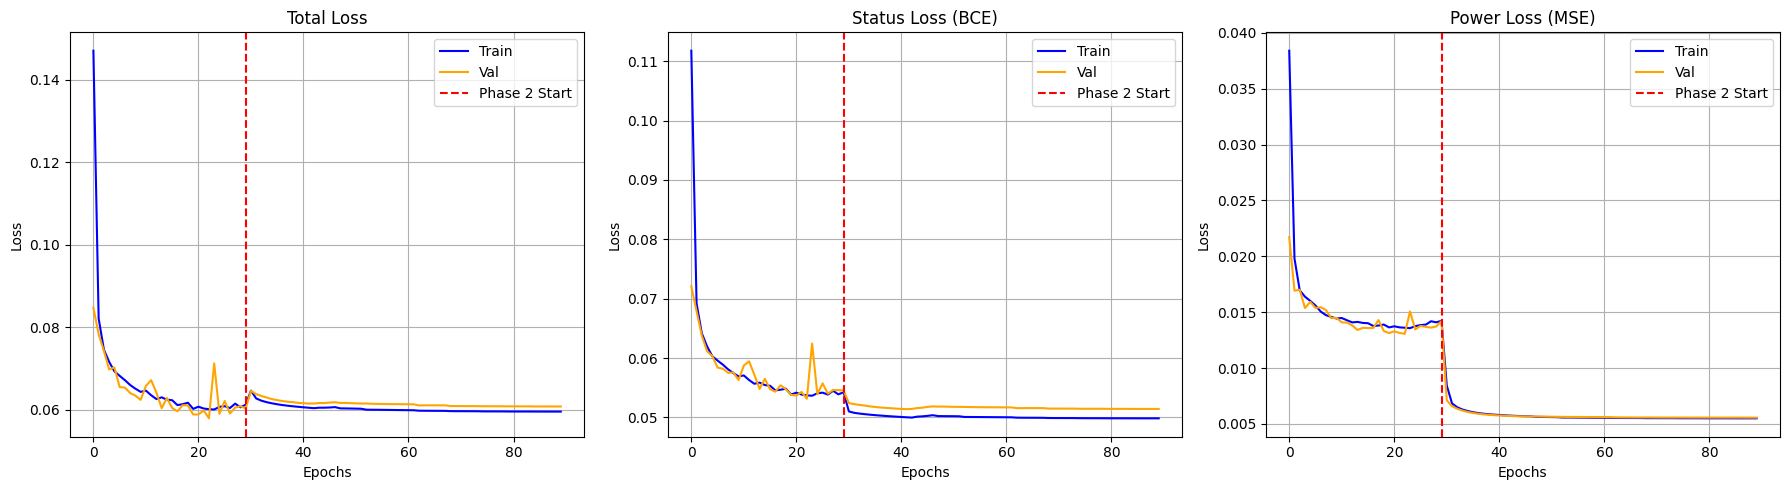

In [10]:
# ---------------------------------------------------------
# 8. Loss Curve 시각화 (Phase 1 & Phase 2 연결)
# ---------------------------------------------------------
import matplotlib.pyplot as plt

def plot_two_phase_loss(hist1, hist2):
    # 두 히스토리의 데이터 병합
    def merge_metric(metric_name):
        return hist1.history[metric_name] + hist2.history[metric_name]

    metrics = ['loss', 'val_loss',
               'out_status_loss', 'val_out_status_loss',
               'out_power_loss', 'val_out_power_loss']

    merged_data = {m: merge_metric(m) for m in metrics}
    phase1_epochs = len(hist1.history['loss'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 그래프 그리기 헬퍼 함수
    def plot_ax(ax, train_key, val_key, title, ylabel):
        ax.plot(merged_data[train_key], label='Train', color='blue')
        ax.plot(merged_data[val_key], label='Val', color='orange')
        # Phase 전환 지점 수직선 표시
        ax.axvline(x=phase1_epochs - 1, color='red', linestyle='--', label='Phase 2 Start')
        ax.set_title(title)
        ax.set_xlabel('Epochs')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True)

    # 1. Total Loss
    plot_ax(axes[0], 'loss', 'val_loss', 'Total Loss', 'Loss')
    # 2. Status Loss (BCE)
    plot_ax(axes[1], 'out_status_loss', 'val_out_status_loss', 'Status Loss (BCE)', 'Loss')
    # 3. Power Loss (MSE)
    plot_ax(axes[2], 'out_power_loss', 'val_out_power_loss', 'Power Loss (MSE)', 'Loss')

    plt.tight_layout()
    plt.show()

# 병합된 시각화 실행 (변수명 주의: history_phase1, history_phase2)
plot_two_phase_loss(history_phase1, history_phase2)

[Cell9]

In [11]:
# ---------------------------------------------------------
# [수정된 cell 9] Test Set 평가 (Multi-Input 지원)
# ---------------------------------------------------------
import numpy as np

print("=== Test Set 물리적 제약 기반 최종 평가 시작 ===")

# 💡 수정 포인트: predict() 함수에 [동적 데이터, 정적 데이터] 리스트 전달
pred_status, pred_power_scaled = model.predict([X_demand_test, X_static_test])

# ---------------------------------------------------------
# Status 이진화 및 Power 역정규화
# ---------------------------------------------------------
pred_status_bin = (pred_status > 0.5).astype(int)

pred_power_2d = pred_power_scaled.reshape(-1, NUM_GENS)
pred_power_mw_2d = scaler_power.inverse_transform(pred_power_2d)
pred_power_mw = pred_power_mw_2d.reshape(-1, NUM_HOURS, NUM_GENS)

true_power_2d = Y_power_test.reshape(-1, NUM_GENS)
true_power_mw_2d = scaler_power.inverse_transform(true_power_2d)
true_power_mw = true_power_mw_2d.reshape(-1, NUM_HOURS, NUM_GENS)

SYS_CAPACITY = 7220.0
P_MIN_np = np.array(P_min_vals)
P_MAX_np = np.array(P_max_vals)
RU_np = np.array(RU_vals)
RD_np = np.array(RD_vals)

# 💡 수정 포인트: X_test 대신 X_demand_test 사용
X_test_mw = X_demand_test.squeeze(-1)

# ---------------------------------------------------------
# ML 성능 및 수급 불균형 평가 (Mismatch)
# ---------------------------------------------------------
status_accuracy = np.mean(pred_status_bin == Y_status_test) * 100
power_mae = np.mean(np.abs(pred_power_mw - true_power_mw))

total_pred_power_mw = np.sum(pred_power_mw, axis=-1)
mismatch_mae = np.mean(np.abs(total_pred_power_mw - X_test_mw))

mean_actual_demand_mw = np.mean(X_test_mw)
relative_error_percent = (mismatch_mae / mean_actual_demand_mw) * 100

# ---------------------------------------------------------
# 물리적 제약 위반 (Violation) 검사
# ---------------------------------------------------------
ghost_power_mw = np.maximum(pred_power_mw, 0.0) * (1 - pred_status_bin)
mean_ghost_violation = np.mean(np.sum(ghost_power_mw, axis=-1))
ghost_relative_percent = (mean_ghost_violation / mean_actual_demand_mw) * 100

upper_violation = np.maximum(pred_power_mw - P_MAX_np, 0.0) * pred_status_bin
lower_violation = np.maximum(P_MIN_np - pred_power_mw, 0.0) * pred_status_bin
mean_capacity_violation = np.mean(np.sum(upper_violation + lower_violation, axis=-1))
capacity_relative_percent = (mean_capacity_violation / mean_actual_demand_mw) * 100

delta_p = pred_power_mw[:, 1:, :] - pred_power_mw[:, :-1, :]
stay_on_mask = pred_status_bin[:, 1:, :] * pred_status_bin[:, :-1, :]

ramp_up_violation = np.maximum(delta_p - RU_np, 0.0) * stay_on_mask
ramp_down_violation = np.maximum(-delta_p - RD_np, 0.0) * stay_on_mask
mean_ramp_violation = np.mean(np.sum(ramp_up_violation + ramp_down_violation, axis=-1))
ramp_relative_percent = (mean_ramp_violation / mean_actual_demand_mw) * 100

=== Test Set 물리적 제약 기반 최종 평가 시작 ===
  1/157 ━━━━━━━━━━━━━━━━━━━━ 27s 179ms/step

2026-05-30 22:34:50.525707: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [12]:
# ---------------------------------------------------------
# [수정된 cell 9] Test Set 평가 (Multi-Input 지원)
# ---------------------------------------------------------
import numpy as np

print("=== Test Set 물리적 제약 기반 최종 평가 시작 ===")

# 💡 수정 포인트: predict() 함수에 [동적 데이터, 정적 데이터] 리스트 전달
pred_status, pred_power_scaled = model.predict([X_demand_test, X_static_test])

# ---------------------------------------------------------
# Status 이진화 및 Power 역정규화
# ---------------------------------------------------------
pred_status_bin = (pred_status > 0.5).astype(int)

pred_power_2d = pred_power_scaled.reshape(-1, NUM_GENS)
pred_power_mw_2d = scaler_power.inverse_transform(pred_power_2d)
pred_power_mw = pred_power_mw_2d.reshape(-1, NUM_HOURS, NUM_GENS)

true_power_2d = Y_power_test.reshape(-1, NUM_GENS)
true_power_mw_2d = scaler_power.inverse_transform(true_power_2d)
true_power_mw = true_power_mw_2d.reshape(-1, NUM_HOURS, NUM_GENS)

SYS_CAPACITY = 7220.0
P_MIN_np = np.array(P_min_vals)
P_MAX_np = np.array(P_max_vals)
RU_np = np.array(RU_vals)
RD_np = np.array(RD_vals)

# 💡 수정 포인트: X_test 대신 X_demand_test 사용
X_test_mw = X_demand_test.squeeze(-1)

# ---------------------------------------------------------
# ML 성능 및 수급 불균형 평가 (Mismatch)
# ---------------------------------------------------------
status_accuracy = np.mean(pred_status_bin == Y_status_test) * 100
power_mae = np.mean(np.abs(pred_power_mw - true_power_mw))

total_pred_power_mw = np.sum(pred_power_mw, axis=-1)
mismatch_mae = np.mean(np.abs(total_pred_power_mw - X_test_mw))

mean_actual_demand_mw = np.mean(X_test_mw)
relative_error_percent = (mismatch_mae / mean_actual_demand_mw) * 100

# ---------------------------------------------------------
# 물리적 제약 위반 (Violation) 검사
# ---------------------------------------------------------
ghost_power_mw = np.maximum(pred_power_mw, 0.0) * (1 - pred_status_bin)
mean_ghost_violation = np.mean(np.sum(ghost_power_mw, axis=-1))
ghost_relative_percent = (mean_ghost_violation / mean_actual_demand_mw) * 100

upper_violation = np.maximum(pred_power_mw - P_MAX_np, 0.0) * pred_status_bin
lower_violation = np.maximum(P_MIN_np - pred_power_mw, 0.0) * pred_status_bin
mean_capacity_violation = np.mean(np.sum(upper_violation + lower_violation, axis=-1))
capacity_relative_percent = (mean_capacity_violation / mean_actual_demand_mw) * 100

delta_p = pred_power_mw[:, 1:, :] - pred_power_mw[:, :-1, :]
stay_on_mask = pred_status_bin[:, 1:, :] * pred_status_bin[:, :-1, :]

ramp_up_violation = np.maximum(delta_p - RU_np, 0.0) * stay_on_mask
ramp_down_violation = np.maximum(-delta_p - RD_np, 0.0) * stay_on_mask
mean_ramp_violation = np.mean(np.sum(ramp_up_violation + ramp_down_violation, axis=-1))
ramp_relative_percent = (mean_ramp_violation / mean_actual_demand_mw) * 100

# =========================================================
# 💡 [비용 평가] AI 예측 비용 vs CPLEX 정답지 비용 비교 분석
# =========================================================
import numpy as np

def calculate_total_cost_from_numpy(status_arr, power_mw_arr, linear_cost, noload_cost, su_cost):
    """
    status_arr: (samples, 24, 54) 형태의 기동 상태 (0 or 1)
    power_mw_arr: (samples, 24, 54) 형태의 실제 발전량 (MW)
    linear_cost, noload_cost, su_cost: 데이터셋 스펙에 맞춘 올바른 비용 계수 배열
    """
    samples, hours, gens = status_arr.shape
    total_cost_per_sample = []
    
    for s in range(samples):
        sample_cost = 0
        status = status_arr[s]
        power = power_mw_arr[s]
        
        for t in range(hours):
            # 1. 💡 운전 비용 = (선형 비용 * P) + (무부하 유지 비용 * Status)
            op_cost = np.sum(linear_cost * power[t] + noload_cost * status[t])
            
            # 2. 기동 비용 (Startup Cost) = 이전 시간에 꺼져있다가(0) 켜지면(1) 부과
            if t == 0:
                # 0시 당일 첫 기동 측정
                su_events = np.maximum(status[t] - 0, 0)
            else:
                su_events = np.maximum(status[t] - status[t-1], 0)
            
            st_cost = np.sum(su_cost * su_events)
            
            sample_cost += (op_cost + st_cost)
            
        total_cost_per_sample.append(sample_cost)
        
    return np.mean(total_cost_per_sample) # 평균 1일 비용 리턴

# 1. 정답지 (Ground Truth) 발전량을 0~1 스케일에서 실제 MW 단위로 역정규화
Y_power_mw_test = Y_power_test * P_MAX_VALS

# 2. 비용 계산 실행 
# (이전에 Cell 2.5에서 정의한 LINEAR_COST_VALS, NOLOAD_COST_VALS를 사용합니다)
ai_avg_cost = calculate_total_cost_from_numpy(pred_status_bin, pred_power_mw, LINEAR_COST_VALS, NOLOAD_COST_VALS, SU_COST_VALS)
cplex_avg_cost = calculate_total_cost_from_numpy(Y_status_test, Y_power_mw_test, LINEAR_COST_VALS, NOLOAD_COST_VALS, SU_COST_VALS)

# 3. 결과 출력
cost_diff = ai_avg_cost - cplex_avg_cost
cost_diff_percent = (cost_diff / cplex_avg_cost) * 100

def calculate_overall_mut_mdt_metrics(all_pred_status, mut_vals, mdt_vals):
    """
    all_pred_status: shape (num_samples, 24, 54) - 테스트 셋 전체의 예측 Status
    """
    num_samples, num_hours, num_gens = all_pred_status.shape
    
    total_mut_violation_hours = 0
    total_mdt_violation_hours = 0
    total_startup_events = 0
    total_shutdown_events = 0
    
    for s in range(num_samples):
        for g in range(num_gens):
            mut = mut_vals[g]
            mdt = mdt_vals[g]
            status = all_pred_status[s, :, g]
            
            for t in range(1, num_hours):
                # 기동 (Startup)
                if status[t-1] == 0 and status[t] == 1:
                    total_startup_events += 1
                    check_len = min(mut, num_hours - t)
                    actual_on = np.sum(status[t : t+check_len])
                    if actual_on < check_len:
                        total_mut_violation_hours += (check_len - actual_on)
                        
                # 정지 (Shutdown)
                elif status[t-1] == 1 and status[t] == 0:
                    total_shutdown_events += 1
                    check_len = min(mdt, num_hours - t)
                    actual_on = np.sum(status[t : t+check_len])
                    if actual_on > 0:
                        total_mdt_violation_hours += actual_on

    # 지표 계산
    avg_mut_violation_per_sample = total_mut_violation_hours / num_samples
    avg_mdt_violation_per_sample = total_mdt_violation_hours / num_samples
    
    print(f"{'='*30}\n[Overall Performance & Physical Constraints]\n{'='*30}")
    print(f"Generator Status (On/Off) Accuracy: {status_accuracy:.2f}%")
    print(f"Mean Absolute Error (MAE) of Power Generation: {power_mae:.2f} MW")
    print(f"Power Balance Violation (Mismatch): {mismatch_mae:.2f} MW ({relative_error_percent:.2f}% NMAE)")
    print(f"Ghost Power Violation: {mean_ghost_violation:.2f} MW ({ghost_relative_percent:.2f}%)")
    print(f"Capacity Violation: {mean_capacity_violation:.2f} MW ({capacity_relative_percent:.2f}%)")
    print(f"Ramp Rate Violation: {mean_ramp_violation:.2f} MW ({ramp_relative_percent:.2f}%)")

    print(f"{'='*30}\n[Economic Evaluation]\n{'='*30}")
    print(f"Average Daily Cost (CPLEX Ground Truth): ${cplex_avg_cost:,.2f}")
    print(f"Average Daily Cost (AI Prediction): ${ai_avg_cost:,.2f}")
    if cost_diff > 0:
        print(f"Cost Difference: The AI model's scheduling is ${cost_diff:,.2f} (+{cost_diff_percent:.2f}%) more expensive than the CPLEX optimal solution.")
    else:
        print(f"Cost Difference: The AI model's scheduling is ${abs(cost_diff):,.2f} ({cost_diff_percent:.2f}%) cheaper than the CPLEX optimal solution. (Note: This slight cost reduction is a theoretical trade-off achieved through minor constraint violations).")

    print(f"{'='*30}\n[Temporal Constraints]\n{'='*30}")
    print(f"Average Minimum Up Time (MUT) Violation: {avg_mut_violation_per_sample:.2f} hours/sample")
    print(f"Average Minimum Down Time (MDT) Violation: {avg_mdt_violation_per_sample:.2f} hours/sample")

# 실행 예시
calculate_overall_mut_mdt_metrics(pred_status_bin, MUT_VALS, MDT_VALS)

=== Test Set 물리적 제약 기반 최종 평가 시작 ===
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[Overall Performance & Physical Constraints]
Generator Status (On/Off) Accuracy: 98.41%
Mean Absolute Error (MAE) of Power Generation: 3.31 MW
Power Balance Violation (Mismatch): 37.08 MW (0.97% NMAE)
Ghost Power Violation: 0.00 MW (0.00%)
Capacity Violation: 1.74 MW (0.05%)
Ramp Rate Violation: 3.01 MW (0.08%)
[Economic Evaluation]
Average Daily Cost (CPLEX Ground Truth): $984,722.56
Average Daily Cost (AI Prediction): $979,730.99
Cost Difference: The AI model's scheduling is $4,991.57 (-0.51%) cheaper than the CPLEX optimal solution. (Note: This slight cost reduction is a theoretical trade-off achieved through minor constraint violations).
[Temporal Constraints]
Average Minimum Up Time (MUT) Violation: 2.65 hours/sample
Average Minimum Down Time (MDT) Violation: 4.28 hours/sample


[Cell10]

=== 개별 샘플 심층 시각화 분석 (Multi-Input 반영) ===


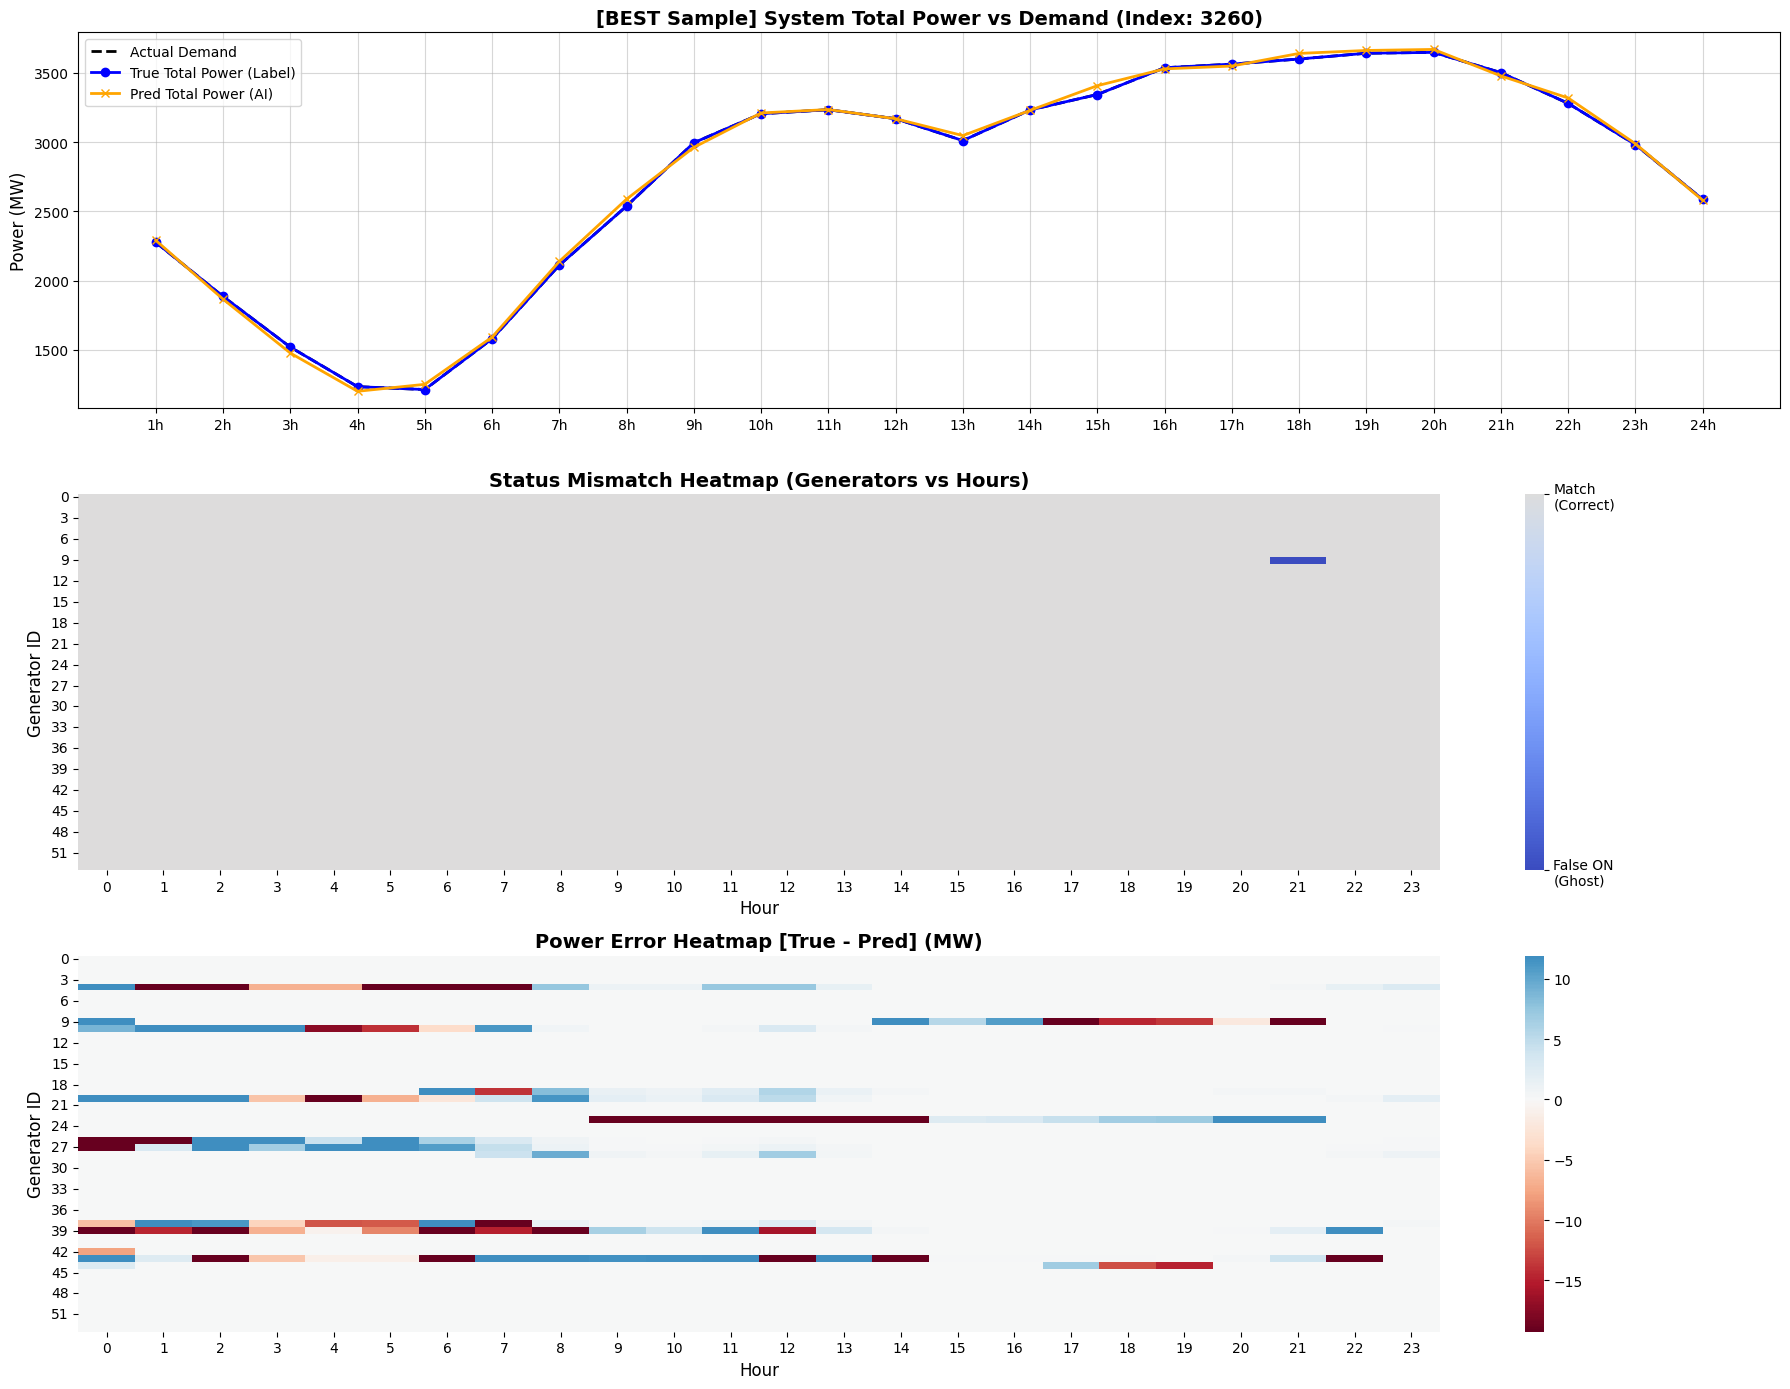

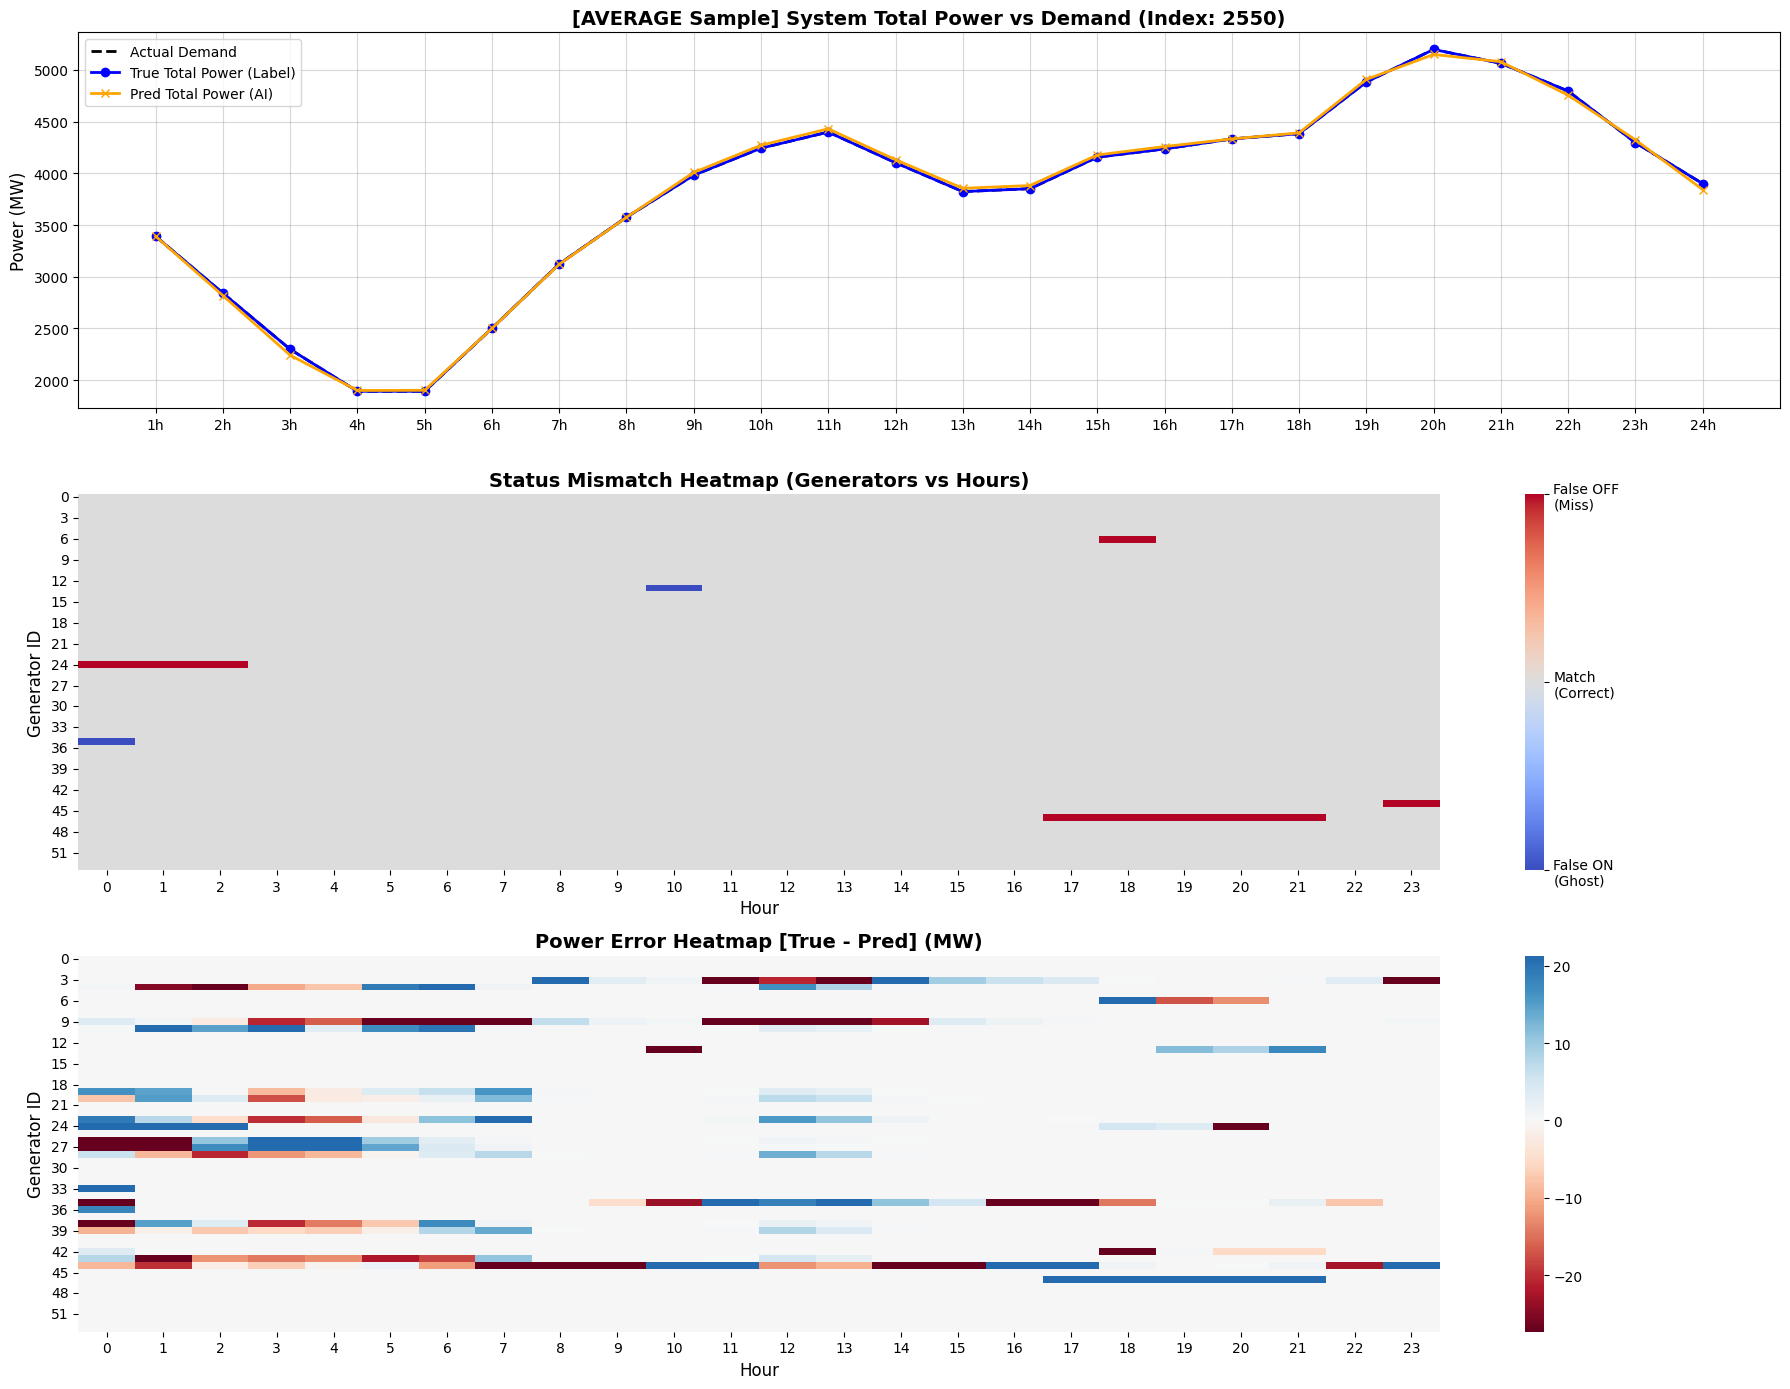

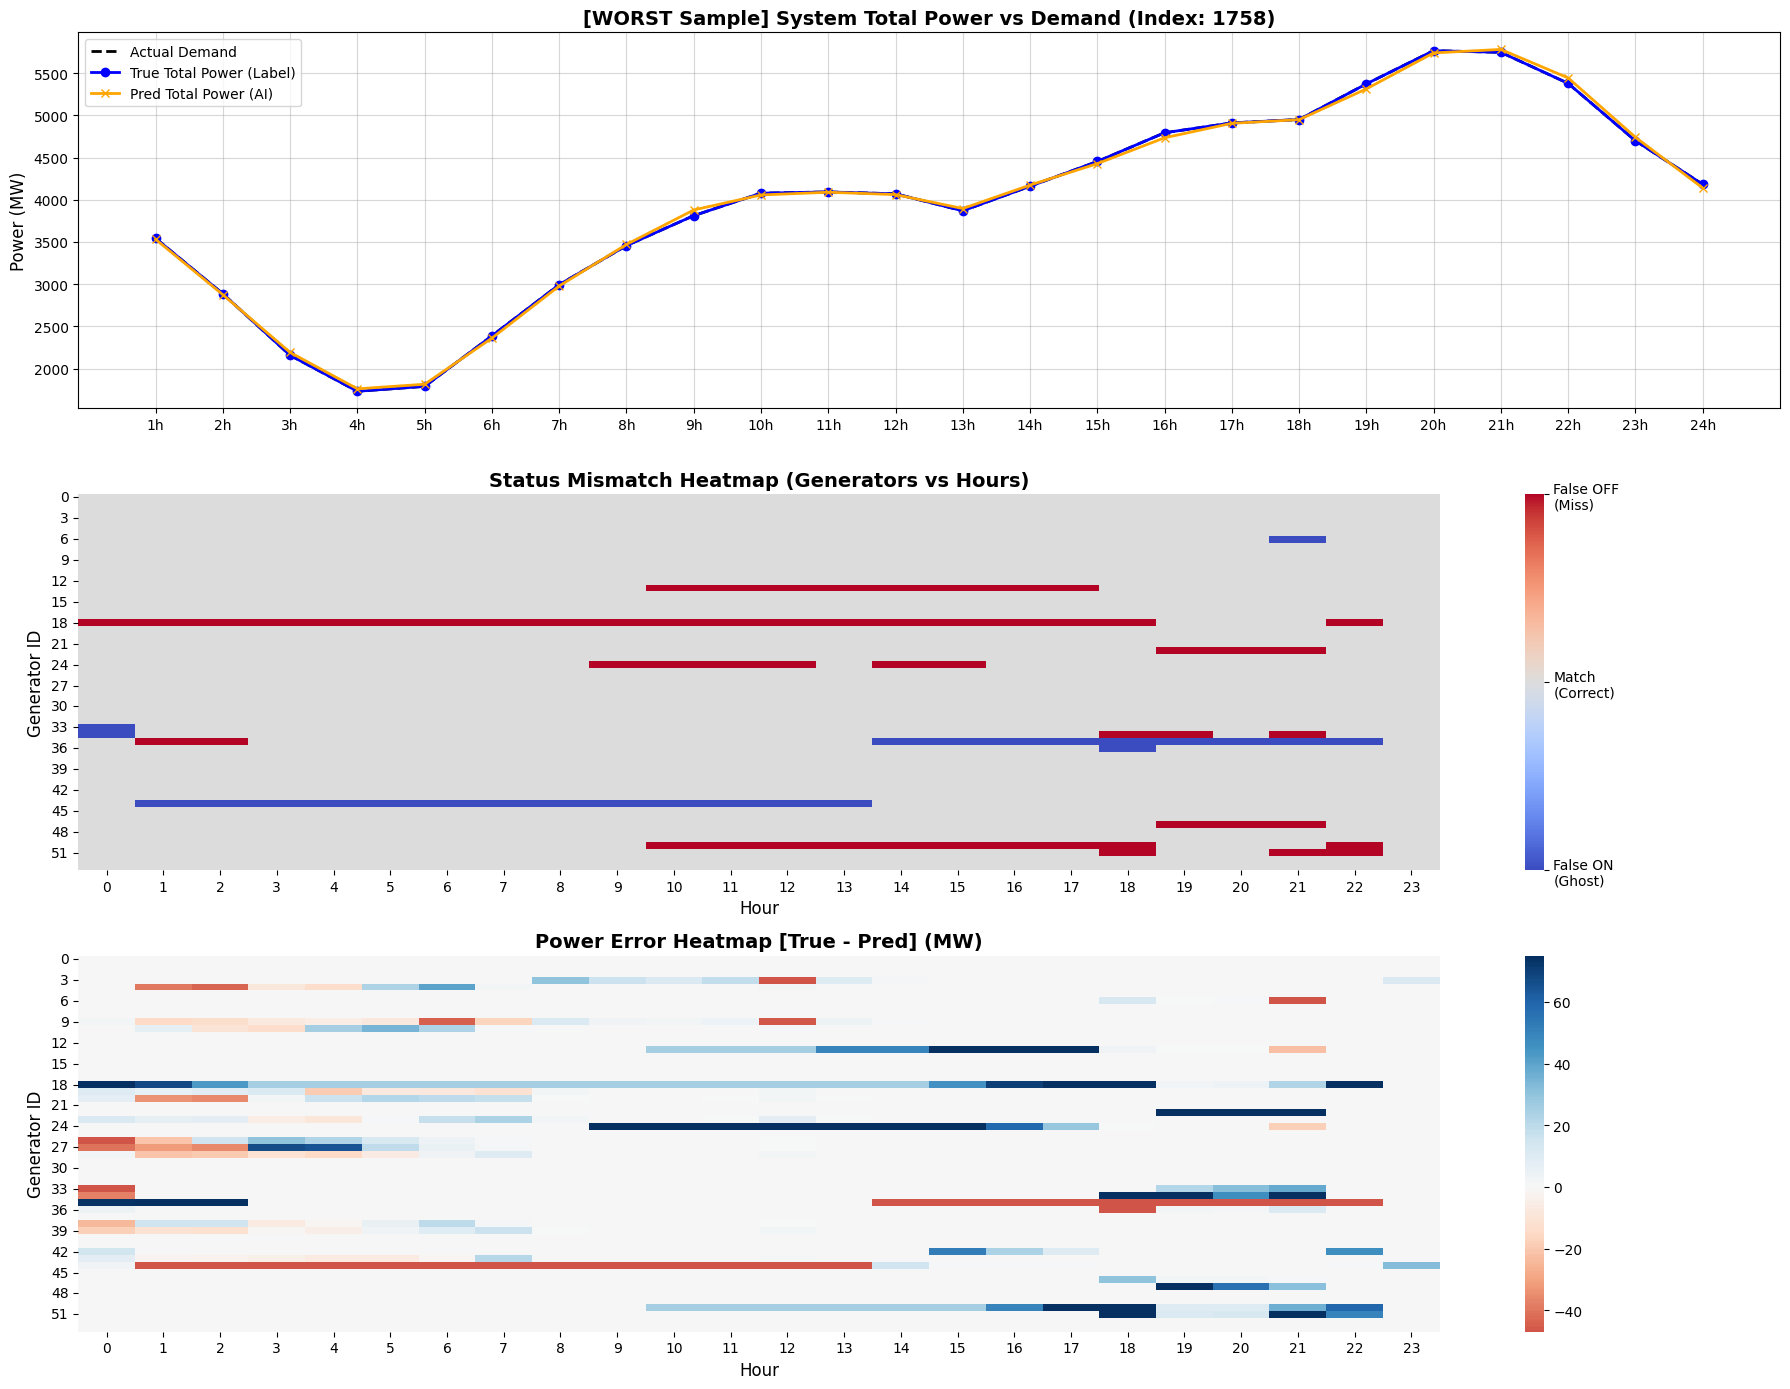

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=== 개별 샘플 심층 시각화 분석 (Multi-Input 반영) ===")

sample_power_errors = np.mean(np.abs(pred_power_mw - true_power_mw), axis=(1, 2))

best_idx = np.argmin(sample_power_errors)
worst_idx = np.argmax(sample_power_errors)
median_error = np.median(sample_power_errors)
avg_idx = np.argmin(np.abs(sample_power_errors - median_error))

def plot_sample_analysis(idx, title_prefix="Sample"):
    fig = plt.figure(figsize=(18, 14))

    t_demand = X_test_mw[idx]
    t_true_power_total = np.sum(true_power_mw[idx], axis=1)
    t_pred_power_total = np.sum(pred_power_mw[idx], axis=1)

    status_diff = Y_status_test[idx] - pred_status_bin[idx]
    power_diff = true_power_mw[idx] - pred_power_mw[idx]

    ax1 = plt.subplot(3, 1, 1)
    ax1.plot(t_demand, label='Actual Demand', color='black', linestyle='--', linewidth=2)
    ax1.plot(t_true_power_total, label='True Total Power (Label)', color='blue', linewidth=2, marker='o')
    ax1.plot(t_pred_power_total, label='Pred Total Power (AI)', color='orange', linewidth=2, marker='x')

    ax1.set_title(f"[{title_prefix}] System Total Power vs Demand (Index: {idx})", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Power (MW)", fontsize=12)
    ax1.set_xticks(range(NUM_HOURS))
    ax1.set_xticklabels([f"{h+1}h" for h in range(NUM_HOURS)])
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.5)

    ax2 = plt.subplot(3, 1, 2)
    sns.heatmap(status_diff.T, cmap='coolwarm', center=0, cbar_kws={'ticks': [-1, 0, 1]}, ax=ax2)
    ax2.set_title("Status Mismatch Heatmap (Generators vs Hours)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Generator ID", fontsize=12)
    ax2.set_xlabel("Hour", fontsize=12)
    cbar = ax2.collections[0].colorbar
    cbar.set_ticklabels(['False ON\n(Ghost)', 'Match\n(Correct)', 'False OFF\n(Miss)'])

    ax3 = plt.subplot(3, 1, 3)
    sns.heatmap(power_diff.T, cmap='RdBu', center=0, ax=ax3, robust=True)
    ax3.set_title("Power Error Heatmap [True - Pred] (MW)", fontsize=14, fontweight='bold')
    ax3.set_ylabel("Generator ID", fontsize=12)
    ax3.set_xlabel("Hour", fontsize=12)

    plt.tight_layout()
    plt.show()

plot_sample_analysis(best_idx, title_prefix="BEST Sample")
plot_sample_analysis(avg_idx, title_prefix="AVERAGE Sample")
plot_sample_analysis(worst_idx, title_prefix="WORST Sample")